
📂 /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/simulation


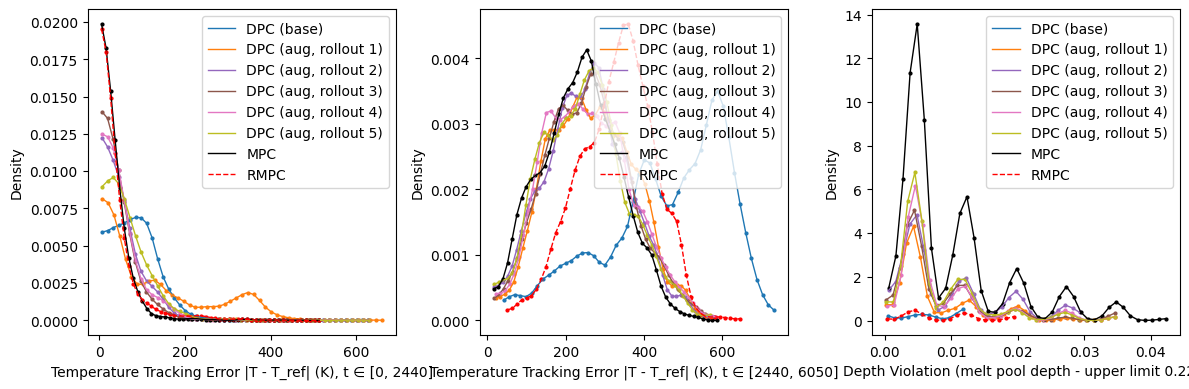

In [5]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ===== 경로 =====
base_pattern = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/simulation"

mpc_csv  = "/home/ftk3187/github/DPC_research/MPC_research_submodule/DED/depth_constrained_rmpc_JMD/profile_1_MPC_w_depth_control_0925.csv"
rmpc_csv = "/home/ftk3187/github/DPC_research/MPC_research_submodule/DED/depth_constrained_rmpc_JMD/profile_1_RMPC_w_depth_control.csv"

base_paths = glob.glob(base_pattern)

epochs = ["0049", "0099", "0149", "0199", "0249", "0299"]

colors = ["#1f77b4", "#ff7f0e", "#9467bd", "#8c564b", "#e377c2", "#bcbd22"]

laser_range = range(1, 2)

LINEWIDTH = 1
dot = 4


# ===== helper =====
def hist_line(ax, data, color, label, linestyle='-'):
    if len(data) == 0:
        return

    p_low = np.percentile(data, 0.5)
    p_high = np.percentile(data, 99.5)
    bins = np.linspace(p_low, p_high, 50)

    hist, edges = np.histogram(data, bins=bins, density=True)
    centers = (edges[:-1] + edges[1:]) / 2

    hist = gaussian_filter1d(hist, sigma=1.2)

    ax.plot(centers, hist, color=color, linewidth=LINEWIDTH, linestyle=linestyle, label=label)
    ax.scatter(centers, hist, color=color, s=dot)


# ===== violation only =====
def plot_violation(ax, depth, color, label, linestyle='-'):
    all_data = depth - 0.225

    if len(all_data) == 0:
        return

    bins = np.linspace(np.min(all_data), np.max(all_data), 800)

    hist, edges = np.histogram(all_data, bins=bins, density=True)
    centers = (edges[:-1] + edges[1:]) / 2

    hist = gaussian_filter1d(hist, sigma=1.2)

    mask = centers > 0

    ax.plot(centers[mask], hist[mask],
            color=color, linestyle=linestyle, linewidth=LINEWIDTH, label=label)
    ax.scatter(centers[mask], hist[mask], color=color, s=dot)

# ===== legend 이름 =====
def get_label(epoch):
    if epoch == "0049":
        return "DPC (base)"
    else:
        rollout = epochs.index(epoch)  # 1,2,3...
        return f"DPC (aug, rollout {rollout})"


# ===== MPC =====
df_mpc = pd.read_csv(mpc_csv)
mpc_temp = df_mpc["gamma_result_temp"].values[:-1]
mpc_ref  = df_mpc["ref"].values[:-1]
mpc_depth = df_mpc["gamma_result_depth"].values[:-1]

mpc_dist = np.abs(mpc_temp - mpc_ref)
mpc_p1 = mpc_dist[:2440]
mpc_p2 = mpc_dist[2440:6050]


# ===== RMPC =====
df_rmpc = pd.read_csv(rmpc_csv)
rmpc_temp = df_rmpc["gamma_result_temp"].values[:-1]
rmpc_ref  = df_rmpc["ref"].values[:-1]
rmpc_depth = df_rmpc["gamma_result_depth"].values[:-1]

rmpc_dist = np.abs(rmpc_temp - rmpc_ref)
rmpc_p1 = rmpc_dist[:2440]
rmpc_p2 = rmpc_dist[2440:6050]


# ===== main =====
for base_path in base_paths:
    print(f"\n📂 {base_path}")

    for laser_id in laser_range:

        # 🔥 1x3 layout
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))

        for i, epoch in enumerate(epochs):

            folder = os.path.join(base_path, f"policy_roll_epoch{epoch}.pth_clamped(1)")

            ref_file = os.path.join(folder, f"ref_laser_{laser_id}.csv")
            temp_file = os.path.join(folder, f"x_outputs_laser_{laser_id}.csv")

            if not os.path.exists(ref_file):
                continue

            ref = pd.read_csv(ref_file, header=None).iloc[:, 0].values
            df_temp = pd.read_csv(temp_file)

            temp = df_temp.iloc[:, 0].values
            depth = df_temp.iloc[:, 1].values

            ref = ref[1:6050]
            temp = temp[:6050]
            depth = depth[:6050]

            min_len = min(len(ref), len(temp), len(depth))
            ref = ref[:min_len]
            temp = temp[:min_len]
            depth = depth[:min_len]

            dist = np.abs(temp - ref)

            label = get_label(epoch)

            # Temp
            hist_line(axes[0], dist[:2440], colors[i], label)
            hist_line(axes[1], dist[2440:6050], colors[i], label)

            # Violation
            plot_violation(axes[2], depth, colors[i], label)

        # ===== MPC =====
        hist_line(axes[0], mpc_p1, 'black', "MPC")
        hist_line(axes[1], mpc_p2, 'black', "MPC")
        plot_violation(axes[2], mpc_depth, 'black', "MPC")

        # ===== RMPC =====
        hist_line(axes[0], rmpc_p1, 'r', "RMPC", linestyle='--')
        hist_line(axes[1], rmpc_p2, 'r', "RMPC", linestyle='--')
        plot_violation(axes[2], rmpc_depth, 'r', "RMPC", linestyle='--')

        # ===== xlabel =====
        axes[0].set_xlabel("Temperature Tracking Error |T - T_ref| (K), t ∈ [0, 2440]")
        axes[1].set_xlabel("Temperature Tracking Error |T - T_ref| (K), t ∈ [2440, 6050]")
        axes[2].set_xlabel("Depth Violation (melt pool depth - upper limit 0.225)")

        # ===== ylabel =====
        for ax in axes:
            ax.set_ylabel("Density")

        # ===== legend =====
        for ax in axes:
            ax.legend()

        plt.tight_layout()
        plt.show()


📂 /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/simulation


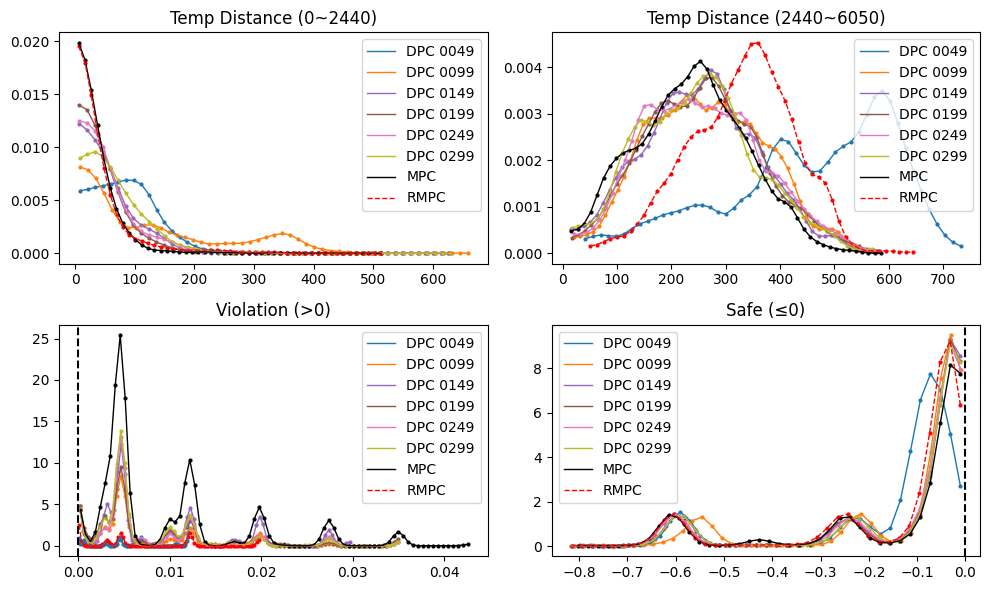

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ===== 경로 =====
base_pattern = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/simulation"

mpc_csv  = "/home/ftk3187/github/DPC_research/MPC_research_submodule/DED/depth_constrained_rmpc_JMD/profile_1_MPC_w_depth_control_0925.csv"
rmpc_csv = "/home/ftk3187/github/DPC_research/MPC_research_submodule/DED/depth_constrained_rmpc_JMD/profile_1_RMPC_w_depth_control.csv"

base_paths = glob.glob(base_pattern)

epochs = ["0049", "0099", "0149", "0199", "0249", "0299"]
colors = ["#c6dbef", "#6baed6", "#3182bd", "#08519c", "#08306b"]
#colors = ["#c7e9c0", "#74c476", "#31a354", "#006d2c", "#00441b"]
#colors = ["#4e79a7", "#f28e2b", "#59a14f", "#b07aa1", "#76b7b2", "#edc948"]
colors = ["#1f77b4", "#ff7f0e", "#9467bd", "#8c564b", "#e377c2", "#bcbd22"]

laser_range = range(1, 2)

# 🔥 여기만 바꾸면 전체 선굵기 변경됨
LINEWIDTH = 1
dot = 4


# ===== helper =====
def hist_line(ax, data, color, label, linestyle='-'):

    if len(data) == 0:
        return

    p_low = np.percentile(data, 0.5)
    p_high = np.percentile(data, 99.5)
    bins = np.linspace(p_low, p_high, 50)

    hist, edges = np.histogram(data, bins=bins, density=True)
    centers = (edges[:-1] + edges[1:]) / 2

    hist = gaussian_filter1d(hist, sigma=1.2)

    ax.plot(centers, hist, color=color, linewidth=LINEWIDTH, linestyle=linestyle, label=label)
    ax.scatter(centers, hist, color=color, s=dot)
    #ax.fill_between(centers, hist, color=color, alpha=0.1)


# ===== 핵심 =====
def plot_safe_violation(ax_safe, ax_violation, depth, color, label, linestyle='-'):

    all_data = depth - 0.225

    if len(all_data) == 0:
        return

    neg_bins = np.linspace(np.min(all_data), 0, 40)
    pos_bins = np.linspace(0, np.max(all_data), 80)
    bins = np.concatenate([neg_bins[:-1], pos_bins])

    hist, edges = np.histogram(all_data, bins=bins, density=True)
    centers = (edges[:-1] + edges[1:]) / 2

    hist = gaussian_filter1d(hist, sigma=1.2)

    violation_mask = centers > 0
    safe_mask = centers <= 0

    # ===== violation =====
    ax_violation.plot(
        centers[violation_mask],
        hist[violation_mask],
        color=color,
        linestyle=linestyle,
        linewidth=LINEWIDTH,
        label=label
    )
    ax_violation.scatter(
        centers[violation_mask],
        hist[violation_mask],
        color=color,
        s=dot
    )
    # ax_violation.fill_between(
    #     centers[violation_mask],
    #     hist[violation_mask],
    #     color=color,
    #     alpha=0.1
    # )

    # ===== safe =====
    ax_safe.plot(
        centers[safe_mask],
        hist[safe_mask],
        color=color,
        linestyle=linestyle,
        linewidth=LINEWIDTH,
        label=label
    )
    ax_safe.scatter(
        centers[safe_mask],
        hist[safe_mask],
        color=color,
        s=dot
    )
    # ax_safe.fill_between(
    #     centers[safe_mask],
    #     hist[safe_mask],
    #     color=color,
    #     alpha=0.1
    # )


# ===== MPC =====
df_mpc = pd.read_csv(mpc_csv)
mpc_temp = df_mpc["gamma_result_temp"].values[:-1]
mpc_ref  = df_mpc["ref"].values[:-1]
mpc_depth = df_mpc["gamma_result_depth"].values[:-1]

mpc_dist = np.abs(mpc_temp - mpc_ref)
mpc_p1 = mpc_dist[:2440]
mpc_p2 = mpc_dist[2440:6050]


# ===== RMPC =====
df_rmpc = pd.read_csv(rmpc_csv)
rmpc_temp = df_rmpc["gamma_result_temp"].values[:-1]
rmpc_ref  = df_rmpc["ref"].values[:-1]
rmpc_depth = df_rmpc["gamma_result_depth"].values[:-1]

rmpc_dist = np.abs(rmpc_temp - rmpc_ref)
rmpc_p1 = rmpc_dist[:2440]
rmpc_p2 = rmpc_dist[2440:6050]


# ===== main =====
for base_path in base_paths:
    print(f"\n📂 {base_path}")

    for laser_id in laser_range:

        # 🔥 1x4 → 2x2 변경
        fig, axes = plt.subplots(2, 2, figsize=(10, 6))

        for i, epoch in enumerate(epochs):
            folder = os.path.join(base_path, f"policy_roll_epoch{epoch}.pth_clamped(1)")

            ref_file = os.path.join(folder, f"ref_laser_{laser_id}.csv")
            temp_file = os.path.join(folder, f"x_outputs_laser_{laser_id}.csv")

            if not os.path.exists(ref_file):
                continue

            ref = pd.read_csv(ref_file, header=None).iloc[:, 0].values
            df_temp = pd.read_csv(temp_file)

            temp = df_temp.iloc[:, 0].values
            depth = df_temp.iloc[:, 1].values

            ref = ref[1:6050]
            temp = temp[:6050]
            depth = depth[:6050]

            min_len = min(len(ref), len(temp), len(depth))
            ref = ref[:min_len]
            temp = temp[:min_len]
            depth = depth[:min_len]

            dist = np.abs(temp - ref)

            # 🔥 Temp (위쪽)
            hist_line(axes[0, 0], dist[:2440], colors[i], f"DPC {epoch}")
            hist_line(axes[0, 1], dist[2440:6050], colors[i], f"DPC {epoch}")

            # 🔥 Depth (아래쪽)
            plot_safe_violation(
                axes[1, 1],  # safe
                axes[1, 0],  # violation
                depth,
                colors[i],
                f"DPC {epoch}"
            )

        # ===== MPC =====
        hist_line(axes[0, 0], mpc_p1, 'black', "MPC")
        hist_line(axes[0, 1], mpc_p2, 'black', "MPC")
        plot_safe_violation(axes[1, 1], axes[1, 0], mpc_depth, 'black', "MPC")

        # ===== RMPC =====
        hist_line(axes[0, 0], rmpc_p1, 'r', "RMPC", linestyle='--')
        hist_line(axes[0, 1], rmpc_p2, 'r', "RMPC", linestyle='--')
        plot_safe_violation(axes[1, 1], axes[1, 0], rmpc_depth, 'r', "RMPC", linestyle='--')

        # ===== 제목 =====
        axes[0, 0].set_title("Temp Distance (0~2440)")
        axes[0, 1].set_title("Temp Distance (2440~6050)")
        axes[1, 0].set_title("Violation (>0)")
        axes[1, 1].set_title("Safe (≤0)")

        # ===== 기준선 =====
        axes[1, 0].axvline(0, color='black', linestyle='--')
        axes[1, 1].axvline(0, color='black', linestyle='--')

        # ===== legend =====
        for row in axes:
            for ax in row:
                ax.legend()

        plt.tight_layout()
        plt.show()

In [14]:
import pandas as pd
import numpy as np

mpc_csv = "/home/ftk3187/github/DPC_research/MPC_research_submodule/DED/depth_constrained_rmpc_JMD/profile_1_RMPC_w_depth_control.csv"
#mpc_csv  = "/home/ftk3187/github/DPC_research/MPC_research_submodule/DED/depth_constrained_rmpc_JMD/profile_1_MPC_w_depth_control_0925.csv"
# ===== 데이터 로드 =====
df = pd.read_csv(mpc_csv)

depth = df["gamma_result_depth"].values

# ===== violation 계산 =====
violation = depth - 0.225
violation_mask = violation > 0

# ===== 결과 =====
total = len(depth)
num_violation = np.sum(violation_mask)
ratio = num_violation / total

print("=== Constraint Violation Summary ===")
print(f"Total points       : {total}")
print(f"Violation count    : {num_violation}")
print(f"Violation ratio    : {ratio:.4f} ({ratio*100:.2f}%)")

# ===== 얼마나 많이 넘는지도 보기 =====
if num_violation > 0:
    print("\n--- Violation Magnitude ---")
    print(f"Mean violation     : {np.mean(violation[violation_mask]):.4f}")
    print(f"Max violation      : {np.max(violation[violation_mask]):.4f}")

=== Constraint Violation Summary ===
Total points       : 6196
Violation count    : 19
Violation ratio    : 0.0031 (0.31%)

--- Violation Magnitude ---
Mean violation     : 0.0088
Max violation      : 0.0199


In [15]:
import os
import glob
import pandas as pd
import numpy as np

# ===== 경로 =====
base_pattern = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/simulation"

base_paths = glob.glob(base_pattern)

# 🔥 보고 싶은 epoch들
epochs = ["0049", "0099", "0149", "0199", "0249", "0299"]

laser_id = 1

for base_path in base_paths:
    print(f"\n📂 {base_path}")

    for ep in epochs:
        print(f"\n=== Epoch {ep} ===")

        folder = os.path.join(
            base_path,
            f"policy_roll_epoch{ep}.pth_clamped(1)"
        )

        temp_file = os.path.join(folder, f"x_outputs_laser_{laser_id}.csv")

        if not os.path.exists(temp_file):
            print("❌ 파일 없음")
            continue

        # ===== 데이터 읽기 =====
        df = pd.read_csv(temp_file)
        depth = df.iloc[:, 1].values

        # ===== shift 보정 =====
        depth = depth[:-1]

        # ===== violation 계산 =====
        violation = depth - 0.225
        violation_mask = violation > 0

        total = len(depth)
        num_violation = np.sum(violation_mask)
        ratio = num_violation / total

        print(f"Total points       : {total}")
        print(f"Violation count    : {num_violation}")
        print(f"Violation ratio    : {ratio:.4f} ({ratio*100:.2f}%)")

        # ===== violation 크기 =====
        if num_violation > 0:
            print(f"Mean violation     : {np.mean(violation[violation_mask]):.4f}")
            print(f"Max violation      : {np.max(violation[violation_mask]):.4f}")


📂 /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/simulation

=== Epoch 0049 ===
Total points       : 6244
Violation count    : 40
Violation ratio    : 0.0064 (0.64%)
Mean violation     : 0.0453
Max violation      : 0.1041

=== Epoch 0099 ===
Total points       : 6244
Violation count    : 151
Violation ratio    : 0.0242 (2.42%)
Mean violation     : 0.0107
Max violation      : 0.0888

=== Epoch 0149 ===
Total points       : 6244
Violation count    : 244
Violation ratio    : 0.0391 (3.91%)
Mean violation     : 0.0142
Max violation      : 0.1194

=== Epoch 0199 ===
Total points       : 6244
Violation count    : 209
Violation ratio    : 0.0335 (3.35%)
Mean violation     : 0.0130
Max violation      : 0.1194

=== Epoch 0249 ===
Total points       : 6244
Violation count    : 215
Violation ratio    : 0.0344 (3


📂 /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_94/or_3L_1024H_s1_c10_ep500_roll50_m51200.0_case_88(*)aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_noinit_layerchangeonlylow_scheduleroff/simulation


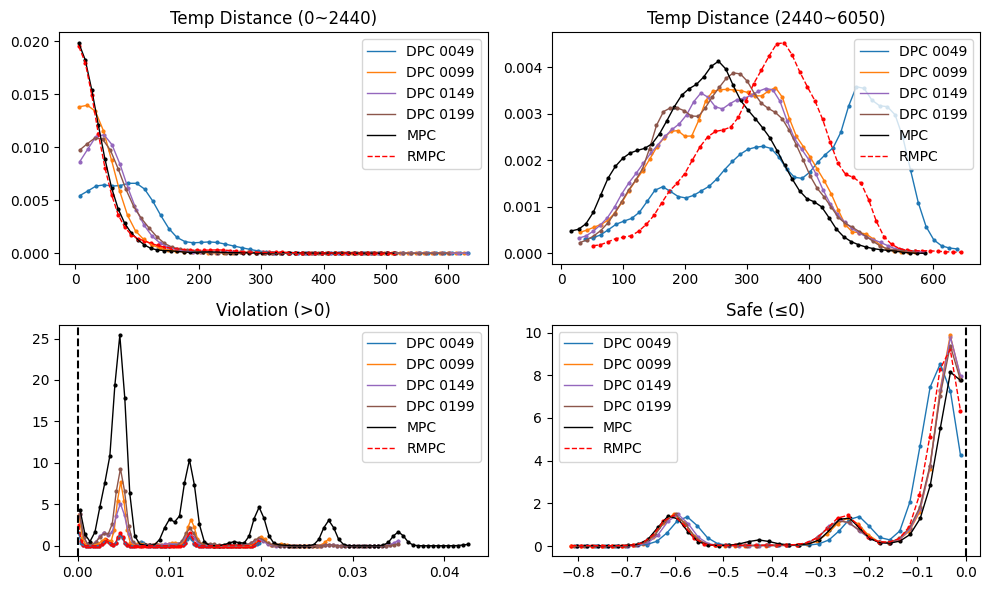

In [16]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ===== 경로 =====
base_pattern = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_94/or_3L_1024H_s1_c10_ep500_roll50_m51200.0_case_88(*)aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_noinit_layerchangeonlylow_scheduleroff/simulation"

mpc_csv  = "/home/ftk3187/github/DPC_research/MPC_research_submodule/DED/depth_constrained_rmpc_JMD/profile_1_MPC_w_depth_control_0925.csv"
rmpc_csv = "/home/ftk3187/github/DPC_research/MPC_research_submodule/DED/depth_constrained_rmpc_JMD/profile_1_RMPC_w_depth_control.csv"

base_paths = glob.glob(base_pattern)

epochs = ["0049", "0099", "0149", "0199", "0249", "0299"]
colors = ["#c6dbef", "#6baed6", "#3182bd", "#08519c", "#08306b"]
#colors = ["#c7e9c0", "#74c476", "#31a354", "#006d2c", "#00441b"]
#colors = ["#4e79a7", "#f28e2b", "#59a14f", "#b07aa1", "#76b7b2", "#edc948"]
colors = ["#1f77b4", "#ff7f0e", "#9467bd", "#8c564b", "#e377c2", "#bcbd22"]

laser_range = range(1, 2)

# 🔥 여기만 바꾸면 전체 선굵기 변경됨
LINEWIDTH = 1
dot = 4


# ===== helper =====
def hist_line(ax, data, color, label, linestyle='-'):

    if len(data) == 0:
        return

    p_low = np.percentile(data, 0.5)
    p_high = np.percentile(data, 99.5)
    bins = np.linspace(p_low, p_high, 50)

    hist, edges = np.histogram(data, bins=bins, density=True)
    centers = (edges[:-1] + edges[1:]) / 2

    hist = gaussian_filter1d(hist, sigma=1.2)

    ax.plot(centers, hist, color=color, linewidth=LINEWIDTH, linestyle=linestyle, label=label)
    ax.scatter(centers, hist, color=color, s=dot)
    #ax.fill_between(centers, hist, color=color, alpha=0.1)


# ===== 핵심 =====
def plot_safe_violation(ax_safe, ax_violation, depth, color, label, linestyle='-'):

    all_data = depth - 0.225

    if len(all_data) == 0:
        return

    neg_bins = np.linspace(np.min(all_data), 0, 40)
    pos_bins = np.linspace(0, np.max(all_data), 80)
    bins = np.concatenate([neg_bins[:-1], pos_bins])

    hist, edges = np.histogram(all_data, bins=bins, density=True)
    centers = (edges[:-1] + edges[1:]) / 2

    hist = gaussian_filter1d(hist, sigma=1.2)

    violation_mask = centers > 0
    safe_mask = centers <= 0

    # ===== violation =====
    ax_violation.plot(
        centers[violation_mask],
        hist[violation_mask],
        color=color,
        linestyle=linestyle,
        linewidth=LINEWIDTH,
        label=label
    )
    ax_violation.scatter(
        centers[violation_mask],
        hist[violation_mask],
        color=color,
        s=dot
    )
    # ax_violation.fill_between(
    #     centers[violation_mask],
    #     hist[violation_mask],
    #     color=color,
    #     alpha=0.1
    # )

    # ===== safe =====
    ax_safe.plot(
        centers[safe_mask],
        hist[safe_mask],
        color=color,
        linestyle=linestyle,
        linewidth=LINEWIDTH,
        label=label
    )
    ax_safe.scatter(
        centers[safe_mask],
        hist[safe_mask],
        color=color,
        s=dot
    )
    # ax_safe.fill_between(
    #     centers[safe_mask],
    #     hist[safe_mask],
    #     color=color,
    #     alpha=0.1
    # )


# ===== MPC =====
df_mpc = pd.read_csv(mpc_csv)
mpc_temp = df_mpc["gamma_result_temp"].values[:-1]
mpc_ref  = df_mpc["ref"].values[:-1]
mpc_depth = df_mpc["gamma_result_depth"].values[:-1]

mpc_dist = np.abs(mpc_temp - mpc_ref)
mpc_p1 = mpc_dist[:2440]
mpc_p2 = mpc_dist[2440:6050]


# ===== RMPC =====
df_rmpc = pd.read_csv(rmpc_csv)
rmpc_temp = df_rmpc["gamma_result_temp"].values[:-1]
rmpc_ref  = df_rmpc["ref"].values[:-1]
rmpc_depth = df_rmpc["gamma_result_depth"].values[:-1]

rmpc_dist = np.abs(rmpc_temp - rmpc_ref)
rmpc_p1 = rmpc_dist[:2440]
rmpc_p2 = rmpc_dist[2440:6050]


# ===== main =====
for base_path in base_paths:
    print(f"\n📂 {base_path}")

    for laser_id in laser_range:

        # 🔥 1x4 → 2x2 변경
        fig, axes = plt.subplots(2, 2, figsize=(10, 6))

        for i, epoch in enumerate(epochs):
            folder = os.path.join(base_path, f"policy_roll_epoch{epoch}.pth_clamped(1)")

            ref_file = os.path.join(folder, f"ref_laser_{laser_id}.csv")
            temp_file = os.path.join(folder, f"x_outputs_laser_{laser_id}.csv")

            if not os.path.exists(ref_file):
                continue

            ref = pd.read_csv(ref_file, header=None).iloc[:, 0].values
            df_temp = pd.read_csv(temp_file)

            temp = df_temp.iloc[:, 0].values
            depth = df_temp.iloc[:, 1].values

            ref = ref[1:6050]
            temp = temp[:6050]
            depth = depth[:6050]

            min_len = min(len(ref), len(temp), len(depth))
            ref = ref[:min_len]
            temp = temp[:min_len]
            depth = depth[:min_len]

            dist = np.abs(temp - ref)

            # 🔥 Temp (위쪽)
            hist_line(axes[0, 0], dist[:2440], colors[i], f"DPC {epoch}")
            hist_line(axes[0, 1], dist[2440:6050], colors[i], f"DPC {epoch}")

            # 🔥 Depth (아래쪽)
            plot_safe_violation(
                axes[1, 1],  # safe
                axes[1, 0],  # violation
                depth,
                colors[i],
                f"DPC {epoch}"
            )

        # ===== MPC =====
        hist_line(axes[0, 0], mpc_p1, 'black', "MPC")
        hist_line(axes[0, 1], mpc_p2, 'black', "MPC")
        plot_safe_violation(axes[1, 1], axes[1, 0], mpc_depth, 'black', "MPC")

        # ===== RMPC =====
        hist_line(axes[0, 0], rmpc_p1, 'r', "RMPC", linestyle='--')
        hist_line(axes[0, 1], rmpc_p2, 'r', "RMPC", linestyle='--')
        plot_safe_violation(axes[1, 1], axes[1, 0], rmpc_depth, 'r', "RMPC", linestyle='--')

        # ===== 제목 =====
        axes[0, 0].set_title("Temp Distance (0~2440)")
        axes[0, 1].set_title("Temp Distance (2440~6050)")
        axes[1, 0].set_title("Violation (>0)")
        axes[1, 1].set_title("Safe (≤0)")

        # ===== 기준선 =====
        axes[1, 0].axvline(0, color='black', linestyle='--')
        axes[1, 1].axvline(0, color='black', linestyle='--')

        # ===== legend =====
        for row in axes:
            for ax in row:
                ax.legend()

        plt.tight_layout()
        plt.show()